<a href="https://colab.research.google.com/github/alurusaivahini-dotcom/trail/blob/main/Agriculture_crop_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Crop_recommendation_dataset.csv")

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'P'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'ph'}>],
       [<Axes: title={'center': 'rainfall'}>, <Axes: >, <Axes: >]],
      dtype=object)

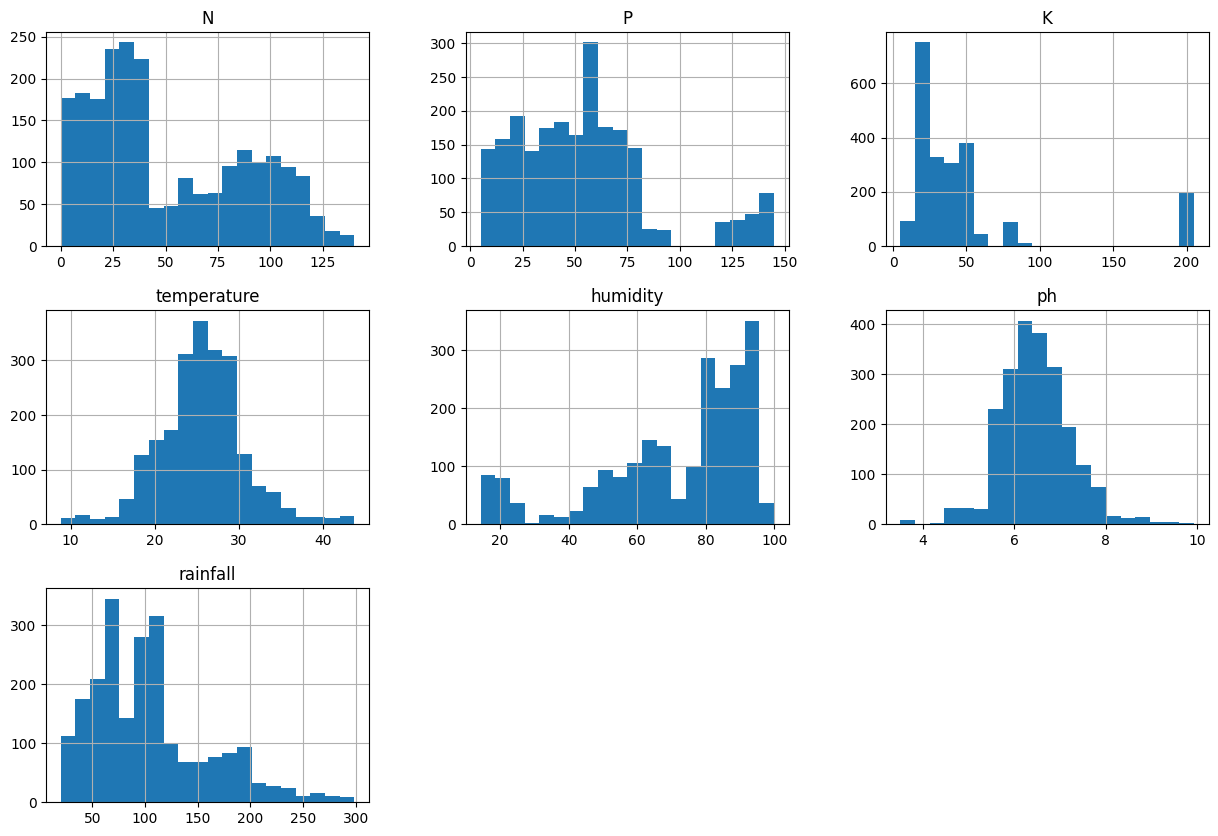

In [ ]:
df.hist(bins=20,figsize=(15,10))

<Axes: ylabel='temperature'>

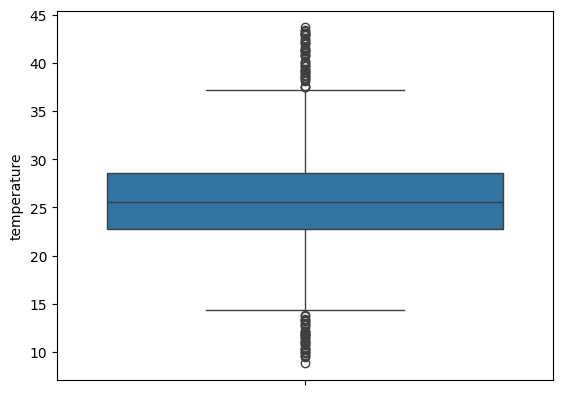

In [ ]:
sns.boxplot(y="temperature",data=df)

<Axes: ylabel='humidity'>

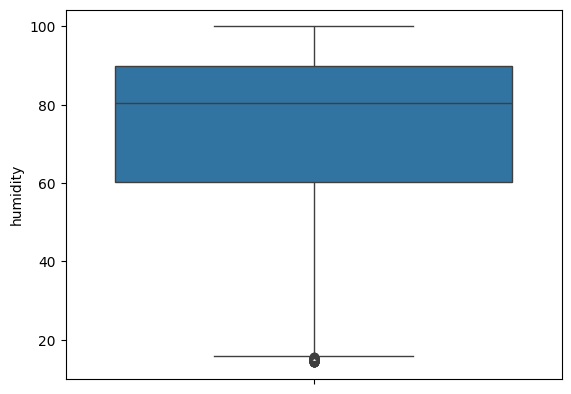

In [ ]:
sns.boxplot(y="humidity",data=df)

<Axes: ylabel='K'>

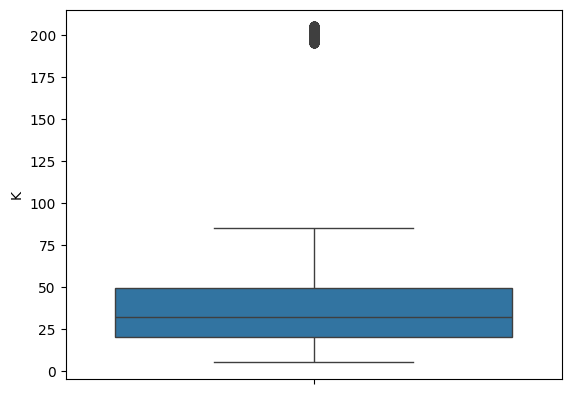

In [ ]:
sns.boxplot(y="K",data=df)

<Axes: ylabel='ph'>

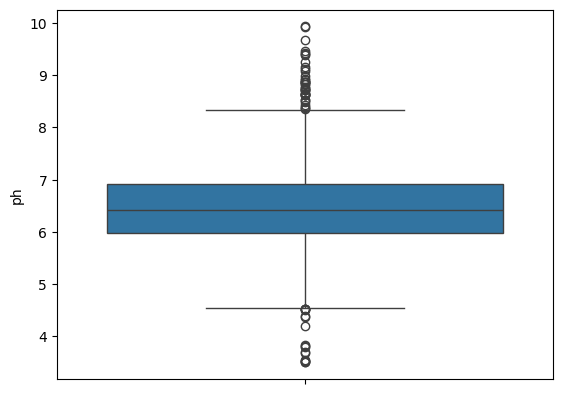

In [ ]:
sns.boxplot(y="ph",data=df)

In [ ]:
def remove_outliers(col_name):
  sorted(col_name)
  Q1,Q3=col_name.quantile([0.25,0.75])
  IQR=Q3-Q1
  lower_range=Q1-(1.5*IQR)
  upper_range=Q3+(1.5*IQR)
  return lower_range,upper_range

In [ ]:
low,high=remove_outliers(df["P"])

In [ ]:
df["P"]=np.where(df["P"]>high,high,np.where(df["P"]<low,low,df["P"]))

<Axes: ylabel='P'>

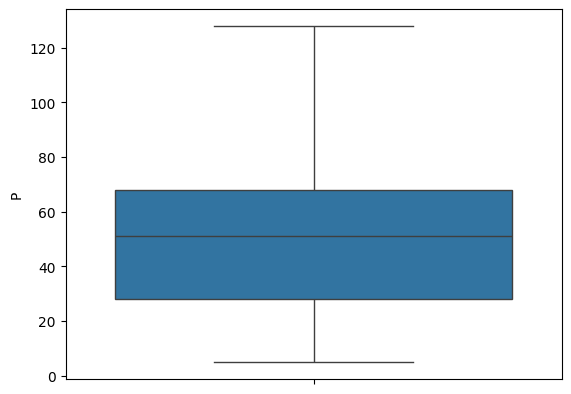

In [ ]:
sns.boxplot(y="P",data=df)

<Axes: ylabel='K'>

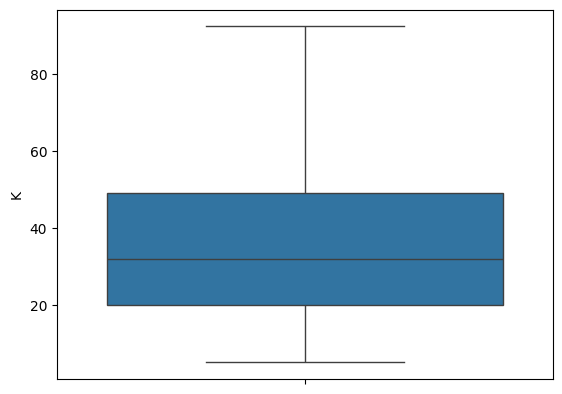

In [ ]:
low,high=remove_outliers(df["K"])
df["K"]=np.where(df["K"]>high,high,np.where(df["K"]<low,low,df["K"]))
sns.boxplot(y="K",data=df)

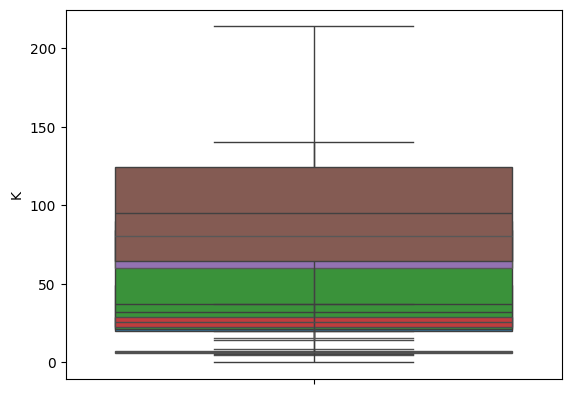

In [ ]:
columns_to_process = ["K", "ph", "N", "temperature", "humidity", "rainfall"]

for col in columns_to_process:
    low, high = remove_outliers(df[col])
    df[col] = np.where(df[col] > high, high, np.where(df[col] < low, low, df[col]))
    sns.boxplot(y=col, data=df)

/tmp/ipykernel_568/4246035388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label",y="ph",data=df,palette="Set3")


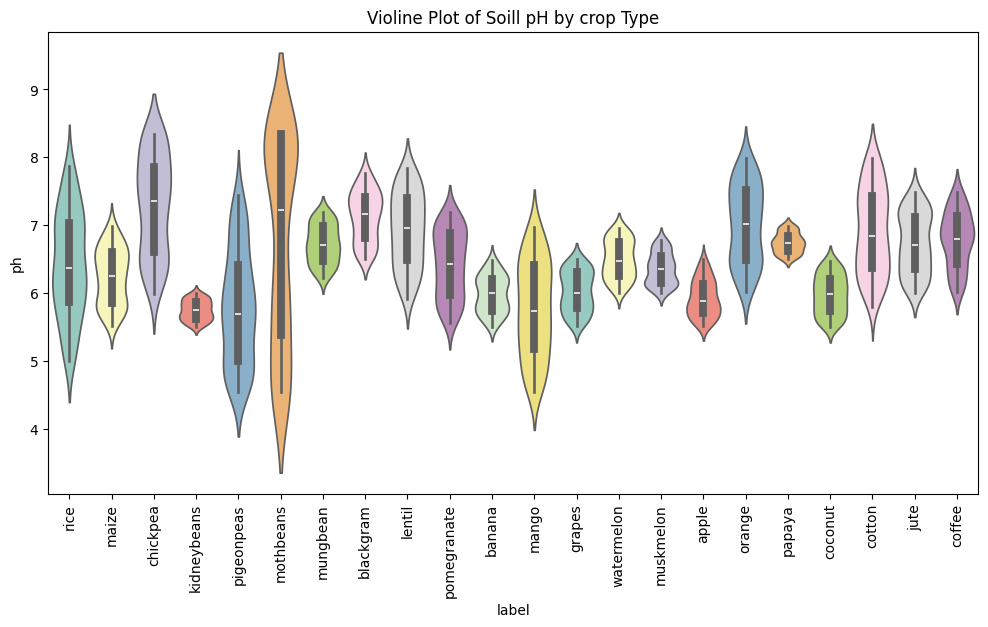

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(x="label",y="ph",data=df,palette="Set3")
plt.title("Violine Plot of Soill pH by crop Type")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='N', ylabel='label'>

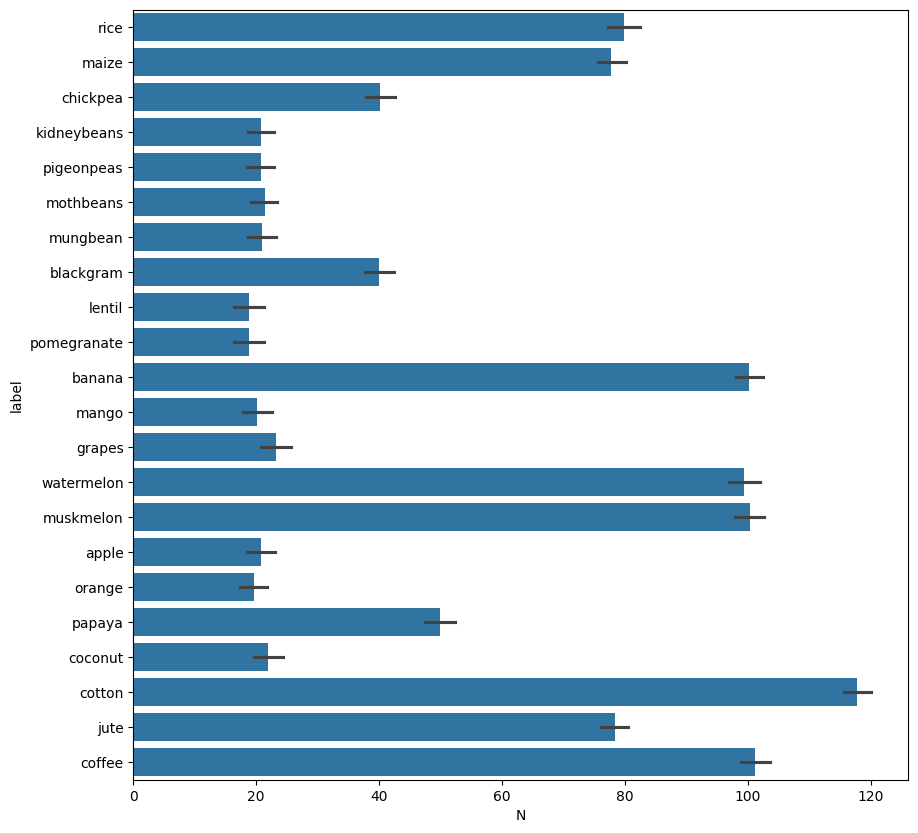

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(y="label",x="N",data=df)

In [ ]:
df.groupby(["label"])["K"].mean().sort_values(ascending=False)

,K
label,
apple,92.50
grapes,92.50
chickpea,79.92
watermelon,50.22
muskmelon,50.08
banana,50.05
papaya,50.04
pomegranate,40.21
jute,39.99
